
WEEK 1


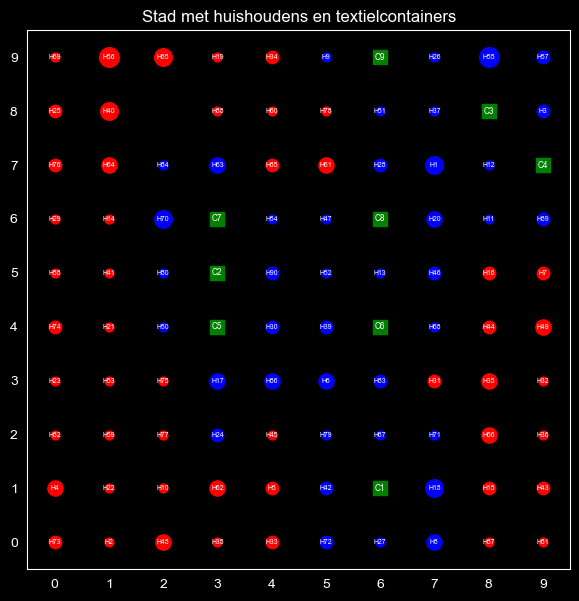


RESULTATEN:

Huishouden   Grootte  Positie      Buren  Opleiding  Inkomen    Geslacht   Afstand    Opgespaard   Recyclewaarde    Recyclegedrag
----------------------------------------------------------------------------------------------------------------------------------
H1           4        (7, 7)       4      laag       midden     vrouw      2.00       2.13         1.02             True      
H2           1        (1, 0)       3      hoog       midden     man        6.00       1.74         -0.04            False     
H3           2        (9, 8)       1      laag       hoog       man        1.00       2.09         1.50             True      
H4           3        (0, 1)       3      hoog       midden     vrouw      6.00       2.13         0.06             False     
H5           2        (4, 1)       4      laag       laag       vrouw      2.00       1.70         0.44             False     
H6           3        (5, 3)       4      laag       midden     man        2.00       1.74

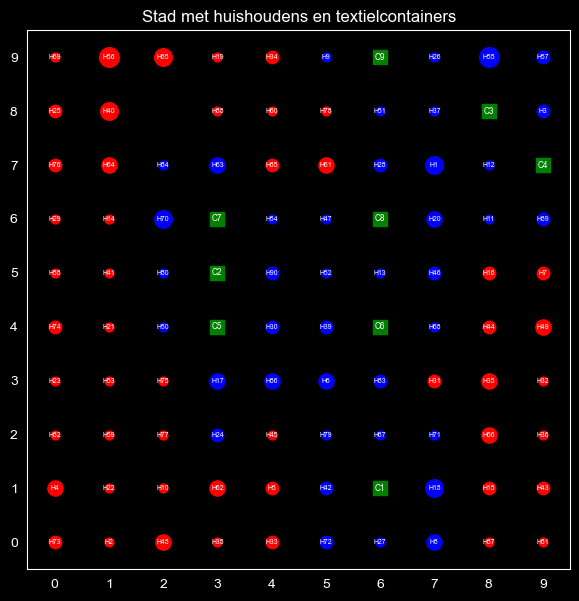


RESULTATEN:

Huishouden   Grootte  Positie      Buren  Opleiding  Inkomen    Geslacht   Afstand    Opgespaard   Recyclewaarde    Recyclegedrag
----------------------------------------------------------------------------------------------------------------------------------
H1           4        (7, 7)       4      laag       midden     vrouw      2.00       4.25         1.02             True      
H2           1        (1, 0)       3      hoog       midden     man        6.00       3.48         -0.04            False     
H3           2        (9, 8)       1      laag       hoog       man        1.00       4.17         1.50             True      
H4           3        (0, 1)       3      hoog       midden     vrouw      6.00       4.25         0.06             False     
H5           2        (4, 1)       4      laag       laag       vrouw      2.00       3.40         0.44             False     
H6           3        (5, 3)       4      laag       midden     man        2.00       3.48

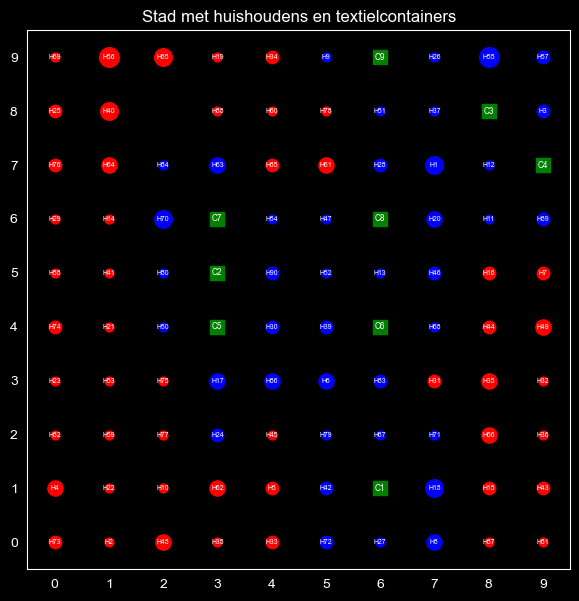


RESULTATEN:

Huishouden   Grootte  Positie      Buren  Opleiding  Inkomen    Geslacht   Afstand    Opgespaard   Recyclewaarde    Recyclegedrag
----------------------------------------------------------------------------------------------------------------------------------
H1           4        (7, 7)       4      laag       midden     vrouw      2.00       6.38         1.02             True      
H2           1        (1, 0)       3      hoog       midden     man        6.00       5.22         -0.04            False     
H3           2        (9, 8)       1      laag       hoog       man        1.00       6.26         1.50             True      
H4           3        (0, 1)       3      hoog       midden     vrouw      6.00       6.38         0.06             False     
H5           2        (4, 1)       4      laag       laag       vrouw      2.00       5.10         0.44             False     
H6           3        (5, 3)       4      laag       midden     man        2.00       5.22

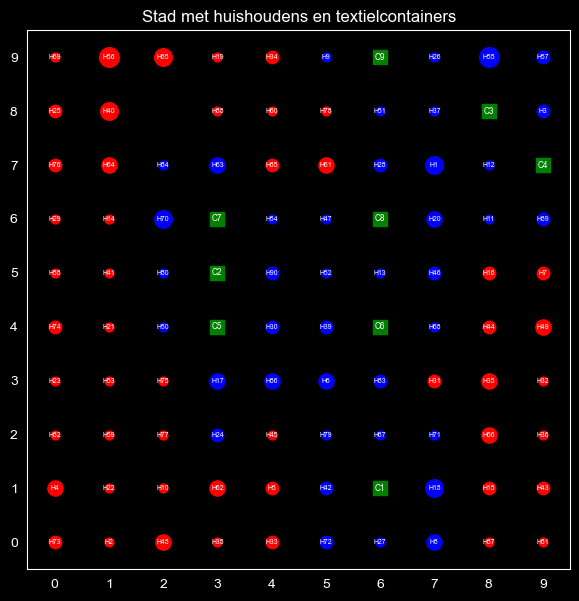


RESULTATEN:

Huishouden   Grootte  Positie      Buren  Opleiding  Inkomen    Geslacht   Afstand    Opgespaard   Recyclewaarde    Recyclegedrag
----------------------------------------------------------------------------------------------------------------------------------
H1           4        (7, 7)       4      laag       midden     vrouw      2.00       8.50         1.02             True      
H2           1        (1, 0)       3      hoog       midden     man        6.00       6.96         -0.04            False     
H3           2        (9, 8)       1      laag       hoog       man        1.00       8.35         1.50             True      
H4           3        (0, 1)       3      hoog       midden     vrouw      6.00       0.00         0.06             False     
H5           2        (4, 1)       4      laag       laag       vrouw      2.00       6.80         0.44             False     
H6           3        (5, 3)       4      laag       midden     man        2.00       0.00

In [1]:
#nieuwste versie 2.0
import random
import math
from mesa import Model, Agent
from mesa.space import MultiGrid
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from IPython.display import HTML
import time


# Agent: huishouden
class Huishouden(Agent):
    def __init__(self, unique_id, model):
        super().__init__(unique_id, model)
        # vaste basisneiging tot recyclen (normaal verdeeld)
        self.basis_recyclewaarde = min(1, max(0, random.normalvariate(0.5, 0.15)))
        self.recyclewaarde = self.basis_recyclewaarde
        self.sociale_gevoeligheid = 0
        self.recyclegedrag = False

        self.opleidingsniveau = random.choice(["laag", "midden", "hoog"])
        self.inkomen = random.choice(["laag", "midden", "hoog"])
        self.geslacht = random.choice(["man", "vrouw"])

        # Huishoudgrootte obvverdeling Nederland 2025
        self.huishoudgrootte = random.choices([1, 2, 3, 4, 5], weights=[55, 26, 9, 7, 3])[0]

        # Basis textielafval: 0,23 kg per persoon per week
        self.textielafval_per_week = 0.23 * self.huishoudgrootte
        self.textielafval_per_tijdstap = self.textielafval_per_week * 4
        self.opgespaard_textielafval = 0

        # Basis textielafval 12 kg/persoon/jaar
        self.textielafval_per_week = 0.23 * 2.10  # kg/huishouden/week
        self.textielafval_per_tijdstap = self.textielafval_per_week * 4
        self.opgespaard_textielafval = 0

        self.weggooifrequentie = max(1, round(random.normalvariate(20, 4))) # in weken
        self.weggooifrequentie = min(40, max(4, self.weggooifrequentie))
        self.weken_tot_weggooien = self.weggooifrequentie

        # Correctie hoeveelheid textielafval obv inkomen
        if self.inkomen == "laag":
            self.textielafval_per_tijdstap *= 0.8
        elif self.inkomen == "hoog":
            self.textielafval_per_tijdstap *= 1.2

        # Correctie hoeveelheid textielafval obv geslacht
        if self.geslacht == "man":
            self.textielafval_per_tijdstap *= 0.9
        elif self.geslacht == "vrouw":
            self.textielafval_per_tijdstap *= 1.1


# Agent: textielcontainer
class Container(Agent):
    def __init__(self, unique_id, model):
        super().__init__(unique_id, model)

        self.capaciteit = 1250          # in kg (5 m³ * 250 kg/m³)
        self.vulgraad = 0
        self.ledigingsfrequentie = 8    # 1 keer per 8 weken
        self.week = 0

    def ledigen(self):
        self.vulgraad = 0


# Model: stad
class Stad(Model):
    def __init__(self, width=10, height=10, num_people=90, people_per_container=10):
        super().__init__()

        self.grid = MultiGrid(width, height, torus=False)

        self.huishoudens = []
        self.containers = []

        self.id = 0
        self.week = 0
        self.drempel = 0.5

        # aantal containers berekenen
        num_containers = math.ceil(num_people / people_per_container)

        # check of alles op het grid past
        totaal_agents = num_people + num_containers
        totaal_cellen = width * height
        if totaal_agents > totaal_cellen:
            raise ValueError(
                f"Te veel agents voor het grid: {totaal_agents} agents voor {totaal_cellen} cellen."
            )

        # alle gehele coördinaten op het grid
        beschikbare_posities = [(x, y) for x in range(width) for y in range(height)]
        random.shuffle(beschikbare_posities)

        # containers plaatsen
        for _ in range(num_containers):
            c = Container(self.next_id(), self)
            pos = beschikbare_posities.pop()
            self.grid.place_agent(c, pos)
            self.containers.append(c)

        # huishoudens plaatsen
        for _ in range(num_people):
            h = Huishouden(self.next_id(), self)
            pos = beschikbare_posities.pop()
            self.grid.place_agent(h, pos)
            self.huishoudens.append(h)

        # eerste berekening
        self.bereken_recyclegedrag()

    def next_id(self):
        self.id += 1
        return self.id

    # Manhattan-afstand op het grid
    def manhattan_afstand(self, pos1, pos2):
        return abs(pos1[0] - pos2[0]) + abs(pos1[1] - pos2[1])

    # dichtstbijzijnde container
    def dichtstbijzijnde_container(self, huishouden):
        beste_container = None
        kleinste_afstand = float("inf")

        for container in self.containers:
            afstand = self.manhattan_afstand(huishouden.pos, container.pos)

            if afstand < kleinste_afstand:
                kleinste_afstand = afstand
                beste_container = container

        return beste_container, kleinste_afstand

    # buurinvloed berekenen:
    # +0.1 voor buur die recycelt
    # -0.1 voor buur die niet recycelt
    def bereken_buurinvloed(self, huishouden):
        x, y = huishouden.pos
        aantal_buren = 0
        buurinvloed = 0

        buur_posities = [
            (x - 1, y),  # links
            (x + 1, y),  # rechts
            (x, y - 1),  # onder
            (x, y + 1)   # boven
        ]

        for bx, by in buur_posities:
            if 0 <= bx < self.grid.width and 0 <= by < self.grid.height:
                inhoud = self.grid.get_cell_list_contents([(bx, by)])

                for agent in inhoud:
                    if isinstance(agent, Huishouden):
                        aantal_buren += 1
                        if agent.recyclegedrag:
                            buurinvloed += 0.1
                        else:
                            buurinvloed -= 0.1

        return aantal_buren, buurinvloed

    # recyclegedrag bepalen
    def bereken_recyclegedrag(self):
        for huishouden in self.huishoudens:
            # basis startwaarde recycle gedrag
            huishouden.recyclewaarde = huishouden.basis_recyclewaarde

            # buurinvloed
            aantal_buren, buurinvloed = self.bereken_buurinvloed(huishouden)
            huishouden.sociale_gevoeligheid = aantal_buren

            # afstand tot dichtstbijzijnde container
            container, afstand = self.dichtstbijzijnde_container(huishouden)
            huishouden.afstand = afstand

            # als huishouden direct naast een container woont -> altijd recyclen
            if afstand == 1:
                huishouden.recyclewaarde = self.drempel + 1
                huishouden.recyclegedrag = True
                continue

            # invloed buren
            huishouden.recyclewaarde += buurinvloed

            # invloed afstand
            huishouden.recyclewaarde -= afstand * 0.025

            # invloed inkomen
            if huishouden.inkomen == "hoog":
                huishouden.recyclewaarde += 0.1
            elif huishouden.inkomen == "laag":
                huishouden.recyclewaarde -= 0.1

            # invloed geslacht
            if huishouden.geslacht == "vrouw":
                huishouden.recyclewaarde += 0.05
            elif huishouden.geslacht == "man":
                huishouden.recyclewaarde -= 0.05

            # beslissing
            huishouden.recyclegedrag = huishouden.recyclewaarde > self.drempel

    # simulatiestap
    def stap(self):
        self.week += 4

        # huishoudens produceren textielafval
        for huishouden in self.huishoudens:
            huishouden.opgespaard_textielafval += huishouden.textielafval_per_tijdstap
            huishouden.weken_tot_weggooien -= 4

        # recyclegedrag opnieuw berekenen
        self.bereken_recyclegedrag()

        # textiel weggooien
        for huishouden in self.huishoudens:
            if huishouden.weken_tot_weggooien <= 0:
                if huishouden.recyclegedrag:
                    container, afstand = self.dichtstbijzijnde_container(huishouden)

                    if container.vulgraad + huishouden.opgespaard_textielafval <= container.capaciteit:
                        container.vulgraad += huishouden.opgespaard_textielafval
                    else:
                        container.vulgraad = container.capaciteit

                huishouden.opgespaard_textielafval = 0
                huishouden.weken_tot_weggooien = huishouden.weggooifrequentie

        # containers legen elke 8 weken
        if self.week % 8 == 0:
            for container in self.containers:
                container.ledigen()

    # resultaten weergeven
    def resultaten(self):
        print("\nRESULTATEN:\n")

        print(f"{'Huishouden':<12} {'Grootte':<8} {'Positie':<12} {'Buren':<6} {'Opleiding':<10} {'Inkomen':<10} {'Geslacht':<10} {'Afstand':<10} {'Opgespaard':<12} {'Recyclewaarde':<16} {'Recyclegedrag':<10}")
        print("-" * 130)

        for i, huishouden in enumerate(self.huishoudens, start=1):
            print(
                f"H{i:<11} "
                f"{huishouden.huishoudgrootte:<8} "
                f"{str(huishouden.pos):<12} "
                f"{huishouden.sociale_gevoeligheid:<6} "
                f"{huishouden.opleidingsniveau:<10} "
                f"{huishouden.inkomen:<10} "
                f"{huishouden.geslacht:<10} "
                f"{huishouden.afstand:<10.2f} "
                f"{huishouden.opgespaard_textielafval:<12.2f} "
                f"{huishouden.recyclewaarde:<16.2f} "
                f"{str(huishouden.recyclegedrag):<10}"
            )

    # visualisatie
    def visualiseer(self):
        plt.figure(figsize=(7, 7))

        for i, h in enumerate(self.huishoudens, start=1):
            x, y = h.pos
            kleur = "blue" if h.recyclegedrag else "red"
            grootte_bol = h.huishoudgrootte * 40
            plt.scatter(x, y, color=kleur, s=grootte_bol)
            plt.text(x, y, f"H{i}", fontsize=5, ha="center", va="center")

        for i, c in enumerate(self.containers, start=1):
            x, y = c.pos
            plt.scatter(x, y, color="green", s=100, marker="s")
            plt.text(x, y, f"C{i}", fontsize=6, ha="center", va="center")

        plt.grid()
        plt.title("Stad met huishoudens en textielcontainers")
        plt.xlim(-0.5, self.grid.width - 0.5)
        plt.ylim(-0.5, self.grid.height - 0.5)
        plt.xticks(range(self.grid.width))
        plt.yticks(range(self.grid.height))
        plt.show()


# model
model = Stad(width=10, height=10, num_people=90, people_per_container=10)

# simulatie
for week in range(4):
    print(f"\nWEEK {week + 1}")
    model.stap()
    model.visualiseer()
    model.resultaten()